<a href="https://colab.research.google.com/github/MtBalbine/PROJETO-1---ESTATISTICA-E-ANALISE-DE-DADOS/blob/main/Tab_varcontinua_classes_Var1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns

Definição de arquivo

In [7]:
arquivo = 'economia_circular.xlsx'
coluna = 'Taxa_Circularidade_percent'

Leitura de Planilha

In [8]:
df=pd.read_excel(arquivo)
df

,Setor,Porte,Taxa_Circularidade_percent,Indice_Sustentabilidade
0,Têxtil,Pequeno,10.5,24.3
1,Têxtil,Médio,14.0,27.0
2,Alimentos,Pequeno,21.2,27.2
3,Alimentos,Médio,16.0,28.1
4,Eletrônicos,Pequeno,19.9,28.9
...,...,...,...,...
273,Metalurgia,Grande,100.0,86.9
274,Metalurgia,Grande,100.0,87.7
275,Metalurgia,Grande,100.0,88.3
276,Plásticos,Grande,100.0,88.8


4. Montando Tabela de classes, indicando os limites de cada classe (note que a amplitude da classe é a mesma para todas as classes)
Neste caso precisamos antes saber o valor mínimo e o valor máximo dos dados para que todos estejam em pelo menos uma das classes.

In [9]:
valormin=df[coluna].min()
valormax=df[coluna].max()
print (valormin,valormax)

10.5 100.0


Definição de Classes


In [10]:
classes = [10,20,30,40,50,60,70,80,90,100]
frequencia = pd.value_counts(pd.cut(x=df[coluna],bins=classes,include_lowest=True,right=False))
frequencia.sort_index(ascending=True)

/tmp/ipykernel_459/2838193740.py:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  frequencia = pd.value_counts(pd.cut(x=df[coluna],bins=classes,include_lowest=True,right=False))


,count
Taxa_Circularidade_percent,
"[10, 20)",24
"[20, 30)",61
"[30, 40)",78
"[40, 50)",36
"[50, 60)",25
"[60, 70)",16
"[70, 80)",14
"[80, 90)",7
"[90, 100)",8


5. Montando Frequência Relativa

In [11]:
Freqpercentual = round(pd.value_counts(pd.cut(x=df[coluna],bins=classes,include_lowest=True,right=False),normalize=True)*100,2)
Freqpercentual.sort_index(ascending=True)

/tmp/ipykernel_459/2202019940.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  Freqpercentual = round(pd.value_counts(pd.cut(x=df[coluna],bins=classes,include_lowest=True,right=False),normalize=True)*100,2)


,proportion
Taxa_Circularidade_percent,
"[10, 20)",8.92
"[20, 30)",22.68
"[30, 40)",29.00
"[40, 50)",13.38
"[50, 60)",9.29
"[60, 70)",5.95
"[70, 80)",5.20
"[80, 90)",2.60
"[90, 100)",2.97


6. Montando as colunas da frequência acumulada e da frequência relativa acumulada


In [12]:
#note que é necessário acumular a coluna da frequência com as classes ordenadas, isto é, usando sort_index
freqacum=np.cumsum(frequencia.sort_index())
freqacum




,count
Taxa_Circularidade_percent,
"[10, 20)",24
"[20, 30)",85
"[30, 40)",163
"[40, 50)",199
"[50, 60)",224
"[60, 70)",240
"[70, 80)",254
"[80, 90)",261
"[90, 100)",269


In [13]:
freqpercacum=np.cumsum(Freqpercentual.sort_index())
freqpercacum

,proportion
Taxa_Circularidade_percent,
"[10, 20)",8.92
"[20, 30)",31.60
"[30, 40)",60.60
"[40, 50)",73.98
"[50, 60)",83.27
"[60, 70)",89.22
"[70, 80)",94.42
"[80, 90)",97.02
"[90, 100)",99.99


7. Arrumando a Tabela

In [14]:
dist_freq = pd.DataFrame({'Frequência': frequencia,'Frequência Relativa (%)':Freqpercentual,'Freq.Acum.': freqacum,'Freq.Rel.Acum. (%)':freqpercacum})
print(dist_freq)
print(f'\n      Variável:{coluna}')
print('     *Limites superiores do intervalo de classes não incluídos')

                            Frequência  Frequência Relativa (%)  Freq.Acum.  \
Taxa_Circularidade_percent                                                    
[10, 20)                            24                     8.92          24   
[20, 30)                            61                    22.68          85   
[30, 40)                            78                    29.00         163   
[40, 50)                            36                    13.38         199   
[50, 60)                            25                     9.29         224   
[60, 70)                            16                     5.95         240   
[70, 80)                            14                     5.20         254   
[80, 90)                             7                     2.60         261   
[90, 100)                            8                     2.97         269   

                            Freq.Rel.Acum. (%)  
Taxa_Circularidade_percent                      
[10, 20)                        

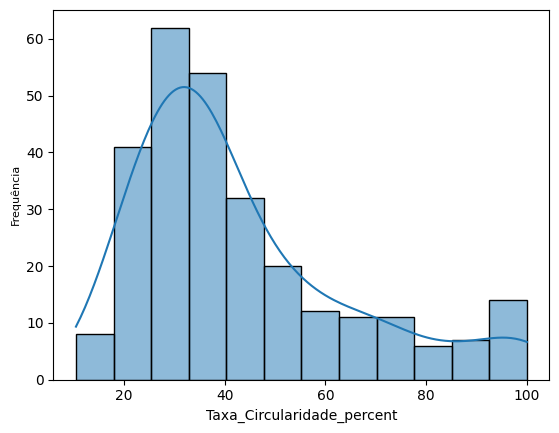

In [15]:
sns.histplot(data=df,x="Taxa_Circularidade_percent",kde=True)
plt.ylabel("Frequência",size=8)
plt.show()